In [22]:
# Try to build a classifier that achieves over 97% accuracy on the test set.
# Use a KNeighborsClassifier
# Use a GridSearch for search a good hyperparameter for KNeighborsClassifier (n_neighbors)
from sklearn.datasets import fetch_openml
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

mnist = fetch_openml('mnist_784', as_frame=False)

X, y = mnist.data, mnist.target
X_train, X_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]

knn_clf = KNeighborsClassifier()
knn_clf.fit(X_train, y_train)
print("predict:",knn_clf.predict([X[0]]))
print("real:", y[0])


predict: ['5']
real: 5


In [23]:
from sklearn.model_selection import cross_val_score
score = cross_val_score(knn_clf, X_train, y_train, cv=3, scoring="accuracy") # Имеет смысл делать до fit, так как он тут сам делает fit 3 раза
print("score для KNeighborsClassifier на train:", score)
# [0.9676  0.9671  0.96755]

score для KNeighborsClassifier на train: [0.9676  0.9671  0.96755]


In [24]:
# Предсказываем на тестовых данных
y_pred = knn_clf.predict(X_test)
# Измеряем ответы y test и предсказанных
print(accuracy_score(y_test, y_pred)) # 0.9688

0.9688


## Fine tune a model

Source - https://www.kaggle.com/code/melihkanbay/knn-best-parameters-gridsearchcv

In [33]:
# This code execute can be like 25 minutes
from sklearn.model_selection import GridSearchCV
# Список [1..31]
k_range = list(range(1, 31))
# Создает поле объекта n_neighbors со списком выше
param_grid = dict(n_neighbors=k_range)
print(param_grid)
# 30 значений n_neighbors × 3 фолда = 90 обучений; Еще потом в конце делает доп обучение и выходит 91 обучение
grid_search = GridSearchCV(knn_clf, param_grid, cv=3, scoring='accuracy')
grid_search.fit(X_train, y_train)

{'n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30]}


KeyboardInterrupt: 

grid_mean_scores
 [0.96755    0.96055    0.96818333 0.96663333 0.96741667 0.9655
 0.9652     0.96435    0.96381667 0.96286667 0.96205    0.96183333
 0.96101667 0.96061667 0.96025    0.95923333 0.95846667 0.95823333
 0.95806667 0.95675    0.95618333 0.95605    0.95535    0.95476667
 0.9541     0.95361667 0.95291667 0.95245    0.95171667 0.95143333]
best_params_
 {'n_neighbors': 3}
best_score_
 0.9681833333333333


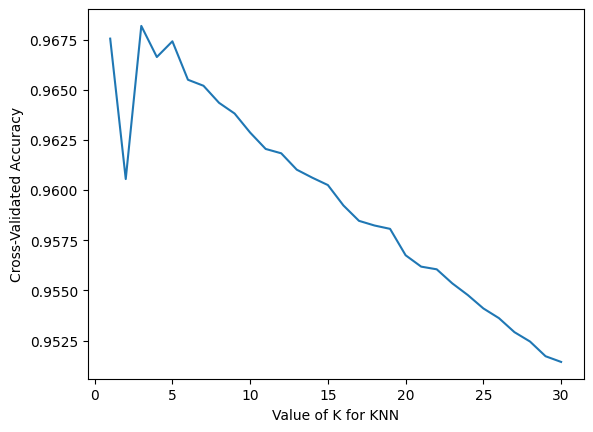

In [ ]:
import matplotlib.pyplot as plt
grid_mean_scores = grid_search.cv_results_['mean_test_score']
print("grid_mean_scores\n", grid_mean_scores)

plt.plot(k_range, grid_mean_scores)
plt.xlabel('Value of K for KNN')
plt.ylabel('Cross-Validated Accuracy')

print("best_params_\n",grid_search.best_params_)
print("best_score_\n",grid_search.best_score_)


In [ ]:
# Trying GridSearch with weights
k_range = list(range(1, 31))
weight_options = ['uniform', 'distance']
param_grid = dict(n_neighbors=k_range, weights=weight_options)
print(param_grid)
grid = GridSearchCV(knn_clf, param_grid, cv=10, scoring='accuracy', return_train_score=False)
grid.fit(X, y)

In [ ]:
# Смотрим результаты 
import pandas as pd
pd.DataFrame(grid.cv_results_)[['mean_test_score', 'std_test_score', 'params']]
print(grid.best_score_)
print(grid.best_params_)